In [1]:
import cv2
import json
import glob
import torch
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.optimize import minimize

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# device = torch.device(
#     "mps" if torch.backends.mps.is_available() else "cpu"
# )
# print(f"Using device: {device}")

In [4]:
SCAN_DIR = "./DTU/scan114"

img1 = cv2.imread(f"{SCAN_DIR}/image/000033.png")
img2 = cv2.imread(f"{SCAN_DIR}/image/000034.png")

# got thiws from the dataset info
K = np.array([[2892.33,    0.  , 823.21],
              [   0.  , 2883.18, 619.07],
              [   0.  ,    0.  ,   1.  ]])
K1 = K2 = K3 = K

In [5]:
sift = cv2.SIFT_create()

In [6]:
def create_matches(des1, des2, kp1, kp2, ratio=0.75, max_query=None):
    des1 = np.asarray(des1, np.float32)
    des2 = np.asarray(des2, np.float32)

    if max_query is not None:
        des1_used = des1[:max_query]
    else:
        des1_used = des1

    matcher = cv2.BFMatcher(cv2.NORM_L2)

    # Match image 1 descriptors to image 2 descriptors
    matches_12 = matcher.knnMatch(des1_used, des2, k=2)

    # Match image 2 descriptors back to image 1 descriptors
    matches_21 = matcher.knnMatch(des2, des1_used, k=2)

    # Store good matches from image 1 -> image 2
    good_12 = {}

    for pair in matches_12:
        if len(pair) < 2:
            continue

        best, second = pair

        if best.distance < ratio * second.distance:
            q_idx = best.queryIdx   # index in des1 / kp1
            t_idx = best.trainIdx   # index in des2 / kp2

            good_12[q_idx] = (t_idx, best.distance)

    # Store good matches from image 2 -> image 1
    good_21 = {}

    for pair in matches_21:
        if len(pair) < 2:
            continue

        best, second = pair

        if best.distance < ratio * second.distance:
            q_idx = best.queryIdx   # index in des2 / kp2
            t_idx = best.trainIdx   # index in des1 / kp1

            good_21[q_idx] = (t_idx, best.distance)

    # Mutual check
    mutual_matches = []

    for idx1, (idx2, dist12) in good_12.items():

        # Does image2 keypoint idx2 also choose image1 keypoint idx1?
        if idx2 in good_21:
            back_idx1, dist21 = good_21[idx2]

            if back_idx1 == idx1:
                mutual_matches.append(
                    (
                        kp1[idx1],
                        kp2[idx2],
                        des1[idx1],
                        des2[idx2],
                        float(dist12),
                        idx1, idx2,
                    )
                )

    mutual_matches = sorted(mutual_matches, key=lambda x: x[4])

    return mutual_matches



In [7]:
def normalize_points(pts):
    """pts: (N, 2) array of pixel coords"""
    centroid = pts.mean(axis=0)
    shifted = pts - centroid
    mean_dist = np.sqrt((shifted**2).sum(axis=1)).mean()
    scale = np.sqrt(2) / mean_dist

    T = np.array([[scale, 0,     -scale * centroid[0]],
                  [0,     scale, -scale * centroid[1]],
                  [0,     0,      1                  ]])
    return T

In [8]:
def create_pixel_mat_for_fundamental_matrix(matches):
    # now since we have the points matched , we can try to fidn the essential matrix to find the relative pose bw the two cams
    # we'll use 8 point method to do that
    # find 8 (u,v )s first
    # each match is basically (u1, v1) ---- (matched to ) ---- (u2, v2)
    # itsa a keypoiiunt pobject which has a member variable called "pt" so just  to match[0].pt ( for a tuple of the coord sof the first point of thte match u1, v1)
    
    # normalize
    pts1 = np.array([m[0].pt for m in matches[:]])
    pts2 = np.array([m[1].pt for m in matches[:]])
    T1 = normalize_points(pts1)
    T2 = normalize_points(pts2)
    
    # transform each point: [x, y] -> T @ [x, y, 1]
    def norm_pt(T, pt):
        p = T @ np.array([pt[0], pt[1], 1.0])
        return p[0], p[1]
    
    l = []
    for match in matches:
        u1, v1 = norm_pt(T1, match[0].pt)
        u2, v2 = norm_pt(T2, match[1].pt)
        
        l.append([
            u2*u1, u2*v1, u2,
            v2*u1, v2*v1, v2,
            u1,    v1,    1
        ])
    pixel_mat_fund_mat_calc = np.array(l)

    return pixel_mat_fund_mat_calc, T1, T2

In [9]:
def get_fundamental_matrix(pixel_mat_fund_mat_calc, T1, T2):

    A = pixel_mat_fund_mat_calc
    
    U, S, Vt = np.linalg.svd(A)
    # to understand the next line, go check out the convo i had with gpt, basically the least value of 
    f = Vt[-1]
    F = f.reshape(3, 3)
    
    # F is the estimated 3x3 Fundamental Matrix
    U, S, Vt = np.linalg.svd(F)
    
    # force smallest singular value to zero cause rank 2 max at epi points
    S[-1] = 0
    
    F_rank2 = U @ np.diag(S) @ Vt
    
    # denormalize back to pixel coordinates
    F = T2.T @ F_rank2 @ T1
    return F

In [10]:
def triangulate(R, t, ul, vl, ur, vr, K1, K2):

    fx1 = K1[0, 0]
    fy1 = K1[1, 1]
    ox1 = K1[0, 2]
    oy1 = K1[1, 2]
    
    fx2 = K2[0, 0]
    fy2 = K2[1, 1]
    ox2 = K2[0, 2]
    oy2 = K2[1, 2]
    
    # these are the knows since the calciulation for the R and t has been performed
    a, b, c, d, e, f, g, h, i = list(float(a) for a  in R.flatten())

    # the values of this matrix have come from manual pen paper calculation
    # basically  istead of using the coinventional method (couldn't be asked idk what it is), i used perspective projection equations
    # to solve thje suystem of linear equations -> 4 eqs 3 unknowns (X, Y, Z) the equatrions are derived from perspective proejction - mentioned above
    # its obvious but we're solving for [x, y, z] the world coordinates of the obejct or point rather
    A = np.array(
        [
            [fx1, 0, (ox1 - ul)], 
            [0, fy1, (oy1 - vl)], 
            [g * (vr - oy2) - fy2 * d, h * (vr - oy2) - fy2 * e, i * (vr - oy2) - fy2 * f],
            [g * (ur - ox2) - fx2 * a, h * (ur - ox2) - fx2 * b, i * (ur - ox2) - fx2 * c]
        ])
    
    B = np.array([[0, 0, -1 * (vr - oy2) * t[2] + fy2 * t[1], t[0]*fx2 - (ur - ox2) * t[2]]])

    # solving least sqyares since system of linear equations doens't get solved perfectly due to noise ( ? )
    X, _, _, _ = np.linalg.lstsq (A, B.T)
    return X.flatten()

In [11]:
def get_R_t(e_U, e_S, e_Vt):

    def cheirality_check(R, t, match, K1, K2):
        ul, vl = match[0].pt
        ur, vr = match[1].pt
        X = triangulate(R, t, ul, vl, ur, vr, K1, K2)
        Z1 = float(X[2])
        Z2 = float((R @ X + t)[2])
        return Z1 > 0 and Z2 > 0
    
    
    W = np.array([[ 0, -1,  0],
                  [ 1,  0,  0],
                  [ 0,  0,  1]], dtype=float)
    
    candidates = [
        (e_U @ W.T @ e_Vt,   e_U[:, 2]),
        (e_U @ W.T @ e_Vt,  -e_U[:, 2]),
        (e_U @ W   @ e_Vt,   e_U[:, 2]),
        (e_U @ W   @ e_Vt,  -e_U[:, 2]),
    ]
    
    R, t = None, None
    for R_cand, t_cand in candidates:
        if np.linalg.det(R_cand) < 0:
            R_cand = -R_cand
        if cheirality_check(R_cand, t_cand, matches[0], K1, K2):
            R, t = R_cand, t_cand
            break
    
    return R, t

In [12]:
def get_R_t_Pnp(K, u, v, world_coords, R_init=None, t_init=None):

    def objective(vars, K, u, v, world_coords):
        # params: u and v are both np.shape(N, 1); world_coords is [np.shape(N, 1), np.shape(N, 1), np.shape(N, 1),]                                         
        a, b, c, d, e, f, g, h, i, tx, ty, tz = vars
        fx = K[0, 0]
        fy = K[1, 1]
        ox = K[0, 2]
        oy = K[1, 2]
    
        x, y, z = world_coords
        return np.sum(
            ((u - ox) * (x*g + y*h + z*i + tz) - fx * (x*a + y*b + z*c + tx))**2
            +
            ((v - oy) * (x*g + y*h + z*i + tz) - fy * (x*d + y*e + z*f + ty))**2
        )

    
    constraints = [
        {
            "type": "eq",
            "fun": lambda vars: vars[0]**2 + vars[3]**2 + vars[6]**2 - 1
        },
        {
            "type": "eq",
            "fun": lambda vars: vars[1]**2 + vars[4]**2 + vars[7]**2 - 1
        },
        {
            "type": "eq",
            "fun": lambda vars: vars[2]**2 + vars[5]**2 + vars[8]**2 - 1
        },
        {
            "type": "eq",
            "fun": lambda vars: vars[0] * vars[1] + vars[3] * vars[4] + vars[6] * vars[7]
        },
        {
            "type": "eq",
            "fun": lambda vars: vars[0] * vars[2] + vars[3] * vars[5] + vars[6] * vars[8]
        },
        {
            "type": "eq",
            "fun": lambda vars: vars[1] * vars[2] + vars[4] * vars[5] + vars[7] * vars[8]
        },
    ]

    if R_init is None:
        R_init = np.eye(3, 3, dtype=float)
    if t_init is None:
        t_init = np.zeros((3, 1), dtype=float)
    x0 = np.concatenate((R_init.flatten(), t_init.flatten()))
    
    # R_init = np.eye(3, 3, dtype=float)
    # t_init = np.zeros((3, 1), dtype=float)
    # x0 = np.concatenate((R_init.flatten(), t_init.flatten()))

    result = minimize(
        objective,
        x0,
        args=(K, u, v, world_coords),
        method="SLSQP",
        constraints=constraints
    )
    
    return result.x, result.success, result.message

In [13]:
def sampson_errors(F, pts1, pts2):
    """
    Assumes standard convention:

        p2.T @ F @ p1 = 0

    pts1: points from image 1, shape (N, 2)
    pts2: points from image 2, shape (N, 2)
    """

    h1 = np.hstack([pts1, np.ones((len(pts1), 1))])  # image 1 homogeneous pts
    h2 = np.hstack([pts2, np.ones((len(pts2), 1))])  # image 2 homogeneous pts

    Fx1 = (F @ h1.T).T        # epipolar lines in image 2
    Ftx2 = (F.T @ h2.T).T     # epipolar lines in image 1

    num = np.sum(h2 * Fx1, axis=1) ** 2

    den = (
        Fx1[:, 0]**2 +
        Fx1[:, 1]**2 +
        Ftx2[:, 0]**2 +
        Ftx2[:, 1]**2
    )

    return np.sqrt(num / (den + 1e-12))


def fundamental_ransac(matches, iters=3000, thresh=1.0, seed=0):
    rng = np.random.default_rng(seed)

    pts1 = np.array([m[0].pt for m in matches])
    pts2 = np.array([m[1].pt for m in matches])

    N = len(matches)
    best_inliers = np.array([], dtype=int)

    for _ in range(iters):
        idx = rng.choice(N, 8, replace=False)
        sub = [matches[k] for k in idx]

        try:
            pm, T1, T2 = create_pixel_mat_for_fundamental_matrix(sub)
            F = get_fundamental_matrix(pm, T1, T2)

        except np.linalg.LinAlgError:
            continue

        err = sampson_errors(F, pts1, pts2)
        inliers = np.where(err < thresh)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers

    # Refit F using all inliers
    inlier_matches = [matches[k] for k in best_inliers]

    pm, T1, T2 = create_pixel_mat_for_fundamental_matrix(inlier_matches)

    F = get_fundamental_matrix(pm, T1, T2)

    return F, best_inliers, inlier_matches

In [14]:
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

In [15]:
matches = create_matches(des1, des2, kp1, kp2, max_query=None)

In [ ]:
matches

In [17]:
pixel_mat_fund_mat_calc, T1, T2 = create_pixel_mat_for_fundamental_matrix(matches)
# F = get_fundamental_matrix(pixel_mat_fund_mat_calc, T1, T2)


n_before = len(matches)                     # total matches BEFORE RANSAC overwrites it
F, inlier_idx, inlier_matches = fundamental_ransac(matches, iters=3000, thresh=1.0)
print(f"F RANSAC: {len(inlier_idx)}/{n_before} inliers")

pts1 = np.array([m[0].pt for m in matches])
pts2 = np.array([m[1].pt for m in matches])
print(f"Sampson after RANSAC: median {np.median(sampson_errors(F, pts1, pts2)):.2f}px")

# nowq to find the essential matrix
E = K2.T @ F @ K1
e_U, e_S, e_Vt = np.linalg.svd(E)

R, t = get_R_t(e_U, e_S, e_Vt)

cam1_coords = K1 @ np.hstack([np.eye(3), np.zeros((3, 1))])
cam2_coords = K2 @ np.hstack([R, t.reshape(3, 1)])

F RANSAC: 1134/1189 inliers
Sampson after RANSAC: median 0.12px


In [18]:
points_3d = []
point_3d_corresponding_kp_list = []

temp = []

for i in range(len(inlier_matches)):
    match = inlier_matches[i]
    ul, vl = match[0].pt
    ur, vr = match[1].pt
    X = triangulate(R, t, ul, vl, ur, vr, K1, K2)
    points_3d.append(X)
    temp.append((match[5], match[6]))

point_3d_corresponding_kp_list.append(temp)

In [19]:
def reproj_err(X, K, R, t, u_obs, v_obs):
    p = R @ X + t
    if p[2] <= 0:
        return np.inf
    u = K[0, 0] * p[0] / p[2] + K[0, 2]
    v = K[1, 1] * p[1] / p[2] + K[1, 2]
    return np.hypot(u - u_obs, v - v_obs)


def reproj_errors_pnp(R, t, K, P, uv):
    """P: (N,3) world pts, uv: (N,2) observed pixels. returns (N,) pixel errors"""
    cam = (R @ P.T).T + t                      # (N,3)
    z = cam[:, 2]
    bad = z <= 0
    z = np.where(bad, 1e-9, z)
    u = K[0, 0] * cam[:, 0] / z + K[0, 2]
    v = K[1, 1] * cam[:, 1] / z + K[1, 2]
    err = np.hypot(u - uv[:, 0], v - uv[:, 1])
    return np.where(bad, np.inf, err)          # behind camera = infinite error

def pnp_ransac(K, P, uv, R_init=None, t_init=None,
               iters=200, sample=8, thresh=4.0, seed=0):
    rng = np.random.default_rng(seed)
    N = len(P)
    if N < sample:
        return None, None, np.array([], dtype=int)

    best_inliers = np.array([], dtype=int)

    for _ in range(iters):
        idx = rng.choice(N, sample, replace=False)
        Ps, uvs = P[idx], uv[idx]

        try:
            tm, ok, _ = get_R_t_Pnp(
                K, uvs[:, 0], uvs[:, 1],
                (Ps[:, 0], Ps[:, 1], Ps[:, 2]),
                R_init, t_init
            )
        except Exception:
            continue
        if not ok:
            continue

        R_c = np.array(tm[:9]).reshape(3, 3)
        t_c = np.array(tm[9:]).reshape(3)

        err = reproj_errors_pnp(R_c, t_c, K, P, uv)
        inliers = np.where(err < thresh)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers

    if len(best_inliers) < sample:
        return None, None, best_inliers

    # refit on all inliers
    Pi, uvi = P[best_inliers], uv[best_inliers]
    tm, ok, _ = get_R_t_Pnp(
        K, uvi[:, 0], uvi[:, 1],
        (Pi[:, 0], Pi[:, 1], Pi[:, 2]),
        R_init, t_init
    )
    if not ok:
        return None, None, best_inliers

    R_f = np.array(tm[:9]).reshape(3, 3)
    t_f = np.array(tm[9:]).reshape(3)
    return R_f, t_f, best_inliers

In [20]:
filenames = glob.glob("./DTU/scan114/image/*")[35:] + glob.glob("./DTU/scan114/image/*")[:35]

In [21]:
image_wise_transformation_mats = {}
for filename in filenames:
    # perspective n points algorithm ig lmfao
    img3 = cv2.imread(filename)
    
    kp3, des3 = sift.detectAndCompute(img3, None)
    matches = create_matches(des2, des3, kp2, kp3, max_query=None)

    temp = len(point_3d_corresponding_kp_list[-1]) * [None]
    claimed = []
    
    for i in range(len(point_3d_corresponding_kp_list[-1])):
        pair = point_3d_corresponding_kp_list[-1][i]
        if pair is not None:
            for j in range(len(matches)):
                match = matches[j]
                if pair[1] == match[-2]: 
                    # take out the kp matches from img2, img3 that have a link to the prev kp matches (has a 3d point)
                    temp[i] = (match[-2], match[-1], j)
                    claimed.append(j)    
                    break
    
    non_corresponding_kp_idx = [j for j in range(len(matches))]
    non_corresponding_kp_idx = list(set(non_corresponding_kp_idx) - set(claimed))
    point_3d_corresponding_kp_list.append(temp)

    points_3d_pnp = []
    pixel_coords_pnp = []

    # create u and v matrices of shape (N, 1)
    for i in range(len(temp)):
        pair = temp[i]
        if pair != None:
            # take the second kp from the pair ( refers to the latter point img 3 in this case bw img 2, img 3)
            u, v = matches[pair[2]][1].pt
            p = points_3d[i]
            points_3d_pnp.append(p)
            pixel_coords_pnp.append([u,v])

    if len(pixel_coords_pnp) == 0:
        break
    pixel_coords_pnp = np.array(pixel_coords_pnp)
    uv = np.array(pixel_coords_pnp)     # (N, 2)
    u = uv[:, 0]                      # (N, 1)
    v = uv[:, 1]

    points_3d_pnp = np.array(points_3d_pnp)

    # ransac so one bad correspondence can't drag the whole pose
    # seeding from the last pose since slsqp is local and the cams are close together
    R_new, t_new, inl = pnp_ransac(K, points_3d_pnp, uv, R, t)

    if R_new is None or len(inl) < 20:
        print(f"skipping {filename}: {len(inl)} inliers")
        kp2, des2 = kp3, des3
        continue

    err = reproj_errors_pnp(R_new, t_new, K, points_3d_pnp, uv)
    print(f"{filename}: {len(inl)}/{len(uv)} inliers, median {np.median(err[inl]):.2f}px")
    print(f"{filename}: R_new={'None' if R_new is None else 'ok'}, inliers={len(inl)}, N={len(uv)}")

    R_prev, t_prev = R, t

    # these are wrt cam1 or the original / initial cam
    R, t = R_new, t_new

    # storing the frame wise poses for later useage ig
    T_curr = np.eye(4, dtype=np.float32)
    T_curr[:3, :3] = R
    T_curr[:3, 3]  = t
    image_wise_transformation_mats[filename] = T_curr
    
    # these are wrt to cam2->cam3
    R_rel = R @ R_prev.T
    t_rel = t - R_rel @ t_prev
    
    # now that we have R and t we triangulat the correspondences of img2, img3
    for idx in non_corresponding_kp_idx:
        X = triangulate(R_rel, t_rel, matches[idx][0].pt[0], matches[idx][0].pt[1], matches[idx][1].pt[0], matches[idx][1].pt[1], K, K)
        if X[2] <= 0:                          # behind cam2
            continue
        if (R_rel @ X + t_rel)[2] <= 0:        # behind cam3
            continue

        e2 = reproj_err(X, K, np.eye(3), np.zeros(3), matches[idx][0].pt[0], matches[idx][0].pt[1])   # cam2 is the origin here
        e3 = reproj_err(X, K, R_rel, t_rel, matches[idx][1].pt[0], matches[idx][1].pt[1])
        if max(e2, e3) > 4.0:
            continue

        # convebrting to cam1 frame before storing  since all  initial points are in cam1 frame
        X_cam1 = R_prev.T @ (X - t_prev)
        points_3d.append(X_cam1)
        # important note for this line
        # pretty confusing but, when img2, img3 temp has say 1000 points, when the new 3d pts are found say 500 new pts after triangulation
        # we need to also add "something" to temp to increase its length to account for the new pts, so the next temp becomes as long as old temp + new pts
        # but if we dont add this line, the next temp will stay 1000 pts and we will continue doing pnp on matches from temp that have existed since the beginnign
        # why matches[idx][-1] this term is the kps that got thrown out cause they didnt have a match, but for future pnp we will add them so t he next 
        # loop (above ^ at the start of the code) doesnt ignore these newly added "soemethings" and checks for mat ches of kps with them as well
        # them being the matches[idx][-1] kps
        temp.append((None, matches[idx][-1], idx))


    kp2, des2 = kp3, des3

./DTU/scan114/image\000035.png: 462/466 inliers, median 1.02px
./DTU/scan114/image\000035.png: R_new=ok, inliers=462, N=466
./DTU/scan114/image\000036.png: 263/284 inliers, median 0.93px
./DTU/scan114/image\000036.png: R_new=ok, inliers=263, N=284
./DTU/scan114/image\000037.png: 111/120 inliers, median 0.78px
./DTU/scan114/image\000037.png: R_new=ok, inliers=111, N=120
./DTU/scan114/image\000038.png: 29/30 inliers, median 0.57px
./DTU/scan114/image\000038.png: R_new=ok, inliers=29, N=30
./DTU/scan114/image\000039.png: 47/48 inliers, median 0.41px
./DTU/scan114/image\000039.png: R_new=ok, inliers=47, N=48
./DTU/scan114/image\000040.png: 31/33 inliers, median 0.50px
./DTU/scan114/image\000040.png: R_new=ok, inliers=31, N=33
./DTU/scan114/image\000041.png: 131/141 inliers, median 0.50px
./DTU/scan114/image\000041.png: R_new=ok, inliers=131, N=141
./DTU/scan114/image\000042.png: 278/299 inliers, median 0.50px
./DTU/scan114/image\000042.png: R_new=ok, inliers=278, N=299
./DTU/scan114/image\

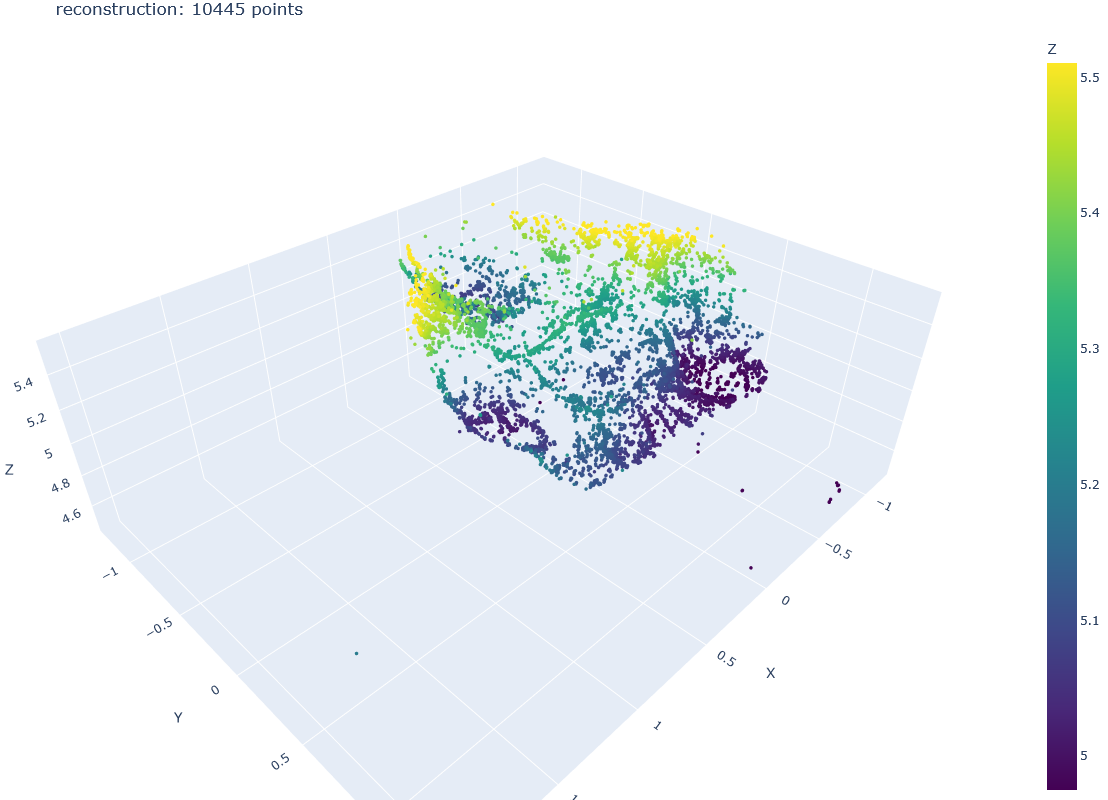

In [30]:
P = np.asarray(points_3d)
z = P[:, 2]
keep = (z > 0) & (z < np.percentile(z[z > 0], 98))
P = P[keep]

cmin, cmax = np.percentile(P[:, 2], [2, 98])      # <-- here

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=P[:, 0], y=P[:, 1], z=P[:, 2],
    mode="markers",
    marker=dict(
        size=2,
        color=P[:, 2],
        colorscale="Viridis",
        cmin=cmin, cmax=cmax,                      # <-- and here
        colorbar=dict(title="Z"),
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        aspectmode="data",
    ),
    width=1000,
    height=800,
    margin=dict(l=0, r=0, t=30, b=0),
    title=f"reconstruction: {len(P)} points",
)

In [31]:
len(points_3d)

10659

In [32]:
len(image_wise_transformation_mats)

29

In [33]:
import glob
import torch
import random
from torch import nn

In [34]:
SCALE = 0.25
H, W = int(1200 * SCALE), int(1600 * SCALE)   # 300, 400

K_small = K.copy()
K_small[:2, :] *= SCALE

In [35]:
points_3d = np.array(points_3d)

In [36]:
# list of dicts
p = points_3d.reshape(-1, 3)
lo, hi = p.min(axis=0), p.max(axis=0)

gaussians = []
for i in range(points_3d.shape[0]):
    for _ in range(random.randint(3, 5)):
        # create a gaussian and append
        gaussians.append({
            "mu": torch.tensor(points_3d[i] + np.random.randn(3) * 0.01, dtype=torch.float32, requires_grad=True, device=device),
            "scale": torch.tensor([0.014, 0.014, 0.014], dtype=torch.float32, requires_grad=True, device=device),
            "rotation": torch.tensor([1.0, 0.0, 0.0, 0.0], dtype=torch.float32, requires_grad=True, device=device),
            "opacity": torch.tensor([0.1], dtype=torch.float32, requires_grad=True, device=device),
            "rgb": torch.tensor([0.5, 0.5, 0.5], dtype=torch.float32, requires_grad=True, device=device)
        })

        # free-floating, uniform in the scene bounding box
        gaussians.append({
            "mu": torch.tensor(np.random.uniform(lo+.5, hi+.5),
                               dtype=torch.float32, requires_grad=True, device=device),
            "scale": torch.tensor([0.014, 0.014, 0.014], dtype=torch.float32, requires_grad=True, device=device),
            "rotation": torch.tensor([1.0, 0.0, 0.0, 0.0], dtype=torch.float32, requires_grad=True, device=device),
            "opacity": torch.tensor([0.1], dtype=torch.float32, requires_grad=True, device=device),
            "rgb": torch.tensor([0.5, 0.5, 0.5], dtype=torch.float32, requires_grad=True, device=device),
        })




In [37]:
class CameraParameters:
    def __init__(self, img_path, intrinsic_mat, transformation_mat):
        self.img_path = img_path
        self.img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        self.img = cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB)
        self.img = cv2.resize(self.img, (W, H), interpolation=cv2.INTER_AREA)
        self.img =  torch.from_numpy(self.img)
        self.img = self.img.to(device)


        intrinsic_mat = torch.as_tensor(
            intrinsic_mat,
            dtype=torch.float32,
            device=device
        )

        transformation_mat = torch.as_tensor(
            transformation_mat,
            dtype=torch.float32,
            device=device
        )
        # focal_length = .5 * self.img.shape[1] / torch.tan( camera_angle / 2)
        self.fx = torch.tensor(intrinsic_mat[0, 0], device=device)
        self.fy = torch.tensor(intrinsic_mat[1, 1], device=device)
        self.cx = torch.tensor(intrinsic_mat[0, 2], device=device)
        self.cy = torch.tensor(intrinsic_mat[1, 2], device=device)
        self.transform_mat = torch.tensor(transformation_mat, device=device)
        # self.world_to_camera = torch.linalg.inv(self.transform_mat)

        self.img = self.img.to(
            device=device,
            dtype=torch.float32
        )

        

        # creating the label imge with the true pixccels
        self.label_img = (
            self.img / 255.0
        ).reshape(-1, 3)
        self.label_img = self.label_img.to(device)
        # self.label_img_tensor = torch.from_numpy(self.label_img).float()

In [38]:
transformation_mats_image_filenames = list(image_wise_transformation_mats.keys())


In [39]:
camera_params_objs = []
# create objects of the class we created
# basically store the camera params object for each image
# this includes the k matrix and the transformatoin matrix (basically both intrinsic and extrinsic for the every image)
# along with the label image in the same calss
for i in range(len(transformation_mats_image_filenames)):
    image_filename = transformation_mats_image_filenames[i]
    cam_param_obj = CameraParameters(image_filename, K_small, image_wise_transformation_mats[image_filename])
    camera_params_objs.append(cam_param_obj)

C:\Users\Aaryadev\AppData\Local\Temp\ipykernel_22540\3565375944.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.fx = torch.tensor(intrinsic_mat[0, 0], device=device)
C:\Users\Aaryadev\AppData\Local\Temp\ipykernel_22540\3565375944.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.fy = torch.tensor(intrinsic_mat[1, 1], device=device)
C:\Users\Aaryadev\AppData\Local\Temp\ipykernel_22540\3565375944.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.cx = torch.tensor(intrinsic_mat[0, 2], device=device)
C:\Users\Aaryade

In [40]:
def get_pixel_coords(pt_3d, fx, fy, cx, cy):
    (x, y, z) = pt_3d
    # function that uses pespecive projection euquations to get u,v
    u, v = fx * x / z + cx, fy * y / z + cy
    return u, v   

def dist(a, b):
    return np.linalg.norm(a - b)

# basic geometry
# ive done it in my notebook, hopefully i'll add an image to my readme
# def get_splat_bbox(u, v, r1, r2, ellipse_top_point_pixel_coords, ellipse_left_point_pixel_coords):
#     u, v, r1, r2 = u, v, r1, r2
#     d = dist(
#         torch.tensor([_ for _ in ellipse_top_point_pixel_coords]),
#         torch.tensor([_ for _ in ellipse_left_point_pixel_coords])
#     )

#     theta = torch.arctan2(r2, r1)

#     x = u - d * torch.cos(theta)
#     y = v - d * torch.sin(theta)

#     w = 2 * r1
#     h = 2 * r2

#     return (
#         int(torch.floor(x[0])),
#         int(torch.floor(y[0])),
#         int(torch.ceil(h[0])),
#         int(torch.ceil(w[0])),
#     )
def get_splat_bbox(
    u,
    v,
    r1,
    r2,
    ellipse_top_point_pixel_coords,
    ellipse_left_point_pixel_coords
):
    u = u.squeeze()
    v = v.squeeze()
    r1 = r1.squeeze()
    r2 = r2.squeeze()

    top = torch.stack(
        [value.squeeze() for value in ellipse_top_point_pixel_coords]
    )

    left = torch.stack(
        [value.squeeze() for value in ellipse_left_point_pixel_coords]
    )

    d = torch.linalg.vector_norm(top - left)
    theta = torch.atan2(r2, r1)

    x_min = torch.floor(u - d * torch.cos(theta)).to(torch.int64)
    y_min = torch.floor(v - d * torch.sin(theta)).to(torch.int64)

    x_max = torch.ceil(u + d * torch.cos(theta)).to(torch.int64)
    y_max = torch.ceil(v + d * torch.sin(theta)).to(torch.int64)

    width = x_max - x_min
    height = y_max - y_min

    return x_min, y_min, width, height


def gaussian_weight(point, mu, scale, eps=1e-8):
    """
    point: tensor([x, y])
    mu:    tensor([u, v])          # Gaussian center
    scale: tensor([sigma_x, sigma_y])
    """

    scale = torch.clamp(scale, min=eps)

    normalized_distance = (point - mu) / scale
    distance_squared = torch.sum(normalized_distance ** 2)

    return torch.exp(-0.5 * distance_squared)

In [41]:
# def generate_image_2d_splats(camera_params_obj, gaussians):
    
#     # for each frame
#     world_to_cam_transform = camera_params_obj.transform_mat
#     image_filename = camera_params_obj.img_path
    
    
#     # create a list of splats
#     # splats belong to an image, not to the global 3d scene
#     # hence new list for all splats for each image we go over
#     image_splats = []
#     for gaussian in gaussians:
#         # comvert mu to cam coords
#         homogenous_mu = torch.cat((gaussian['mu'], torch.tensor([1], device=device)))
#         cam_coords_mu = world_to_cam_transform @ homogenous_mu.reshape(-1, 1)
#         x, y, z = cam_coords_mu[0], cam_coords_mu[1], cam_coords_mu[2], 
        
#         # perspective projection on the screen
#         # this u,v is for he center of the splat or the mean of the gaussian / splat
#         u, v = get_pixel_coords((x, y, z), camera_params_obj.fx, camera_params_obj.fy, camera_params_obj.cx, camera_params_obj.cy)
        
#         # finding the left and right ends of the std dev (sigma ) for each of the axes - x, y, and z
#         x_low, x_high, y_low, y_high, z_low, z_high = cam_coords_mu[0] - 2 * gaussian['scale'][0], cam_coords_mu[0] + 2 * gaussian['scale'][0], cam_coords_mu[1] - 2 * gaussian['scale'][1], cam_coords_mu[1] + 2 * gaussian['scale'][1], cam_coords_mu[2] - 2 * gaussian['scale'][2], cam_coords_mu[2] + 2 * gaussian['scale'][2], 

#         # then finding the u,v (perspective projectoin) values of these ends of the x, y, z values
#         # for eg pt1 (in 3d) (x low) would basically be x_low, y as it is, z as it is
#         # same for the other points
#         pt1 = x_low, cam_coords_mu[1], cam_coords_mu[2]
#         pt2 = x_high, cam_coords_mu[1], cam_coords_mu[2]
        
#         pt3 = cam_coords_mu[0], y_low, cam_coords_mu[2]
#         pt4 = cam_coords_mu[0], y_high, cam_coords_mu[2]

#         # these 4 points define the four corners (if you will) of the splat ( ellipse )
#         u_x_low, v_x_low = get_pixel_coords(pt1, camera_params_obj.fx, camera_params_obj.fy, camera_params_obj.cx, camera_params_obj.cy)
#         u_x_high, v_x_high = get_pixel_coords(pt2, camera_params_obj.fx, camera_params_obj.fy, camera_params_obj.cx, camera_params_obj.cy)
#         u_y_low, v_y_low = get_pixel_coords(pt3, camera_params_obj.fx, camera_params_obj.fy, camera_params_obj.cx, camera_params_obj.cy)
#         u_y_high, v_y_high = get_pixel_coords(pt4, camera_params_obj.fx, camera_params_obj.fy, camera_params_obj.cx, camera_params_obj.cy)


#         r1, r2 =  torch.abs(u_x_low - u_x_high) / 2, torch.abs(v_y_low - v_y_high) / 2
#         x, y, h, w = get_splat_bbox(u, v, r1, r2, [u_y_low, v_y_low], [u_x_low, v_x_low])

#         # saving the semi minor and semi major axes of the ellips image sie
#         # also saving the depth z to later sort gaussians by depth
#         image_splats.append({
#             "u": u,
#             "v": v,
#             "r1": r1,
#             "r2": r2,
#             "depth_z": z,
#             "bbox": {
#                 "x": x,
#                 "y": y,
#                 "h": h,
#                 "w": w
#             },
#             "rgb": gaussian["rgb"],
#             "opacity": gaussian["opacity"],
         
#         })

#     return image_splats

def generate_image_2d_splats(camera_params_obj, gaussians):
    world_to_cam_transform = camera_params_obj.transform_mat
    fx, fy = camera_params_obj.fx, camera_params_obj.fy
    cx, cy = camera_params_obj.cx, camera_params_obj.cy

    # stack every gaussian into one tensor so the projection is a couple of
    # matmuls instead of 25 tiny kernel launches per gaussian
    mu_all    = torch.stack([g['mu']    for g in gaussians])          # (N,3)
    scale_all = torch.stack([g['scale'] for g in gaussians])          # (N,3)
    N = mu_all.shape[0]

    ones = torch.ones((N, 1), device=device, dtype=mu_all.dtype)
    homogenous_mu = torch.cat((mu_all, ones), dim=1)                  # (N,4)

    # (4,4) @ (4,N) -> (4,N) -> (N,4), same as the per-gaussian matmul
    cam_coords = (world_to_cam_transform @ homogenous_mu.T).T         # (N,4)
    x, y, z = cam_coords[:, 0], cam_coords[:, 1], cam_coords[:, 2]

    # perspective projection for the splat centres
    u = fx * x / z + cx
    v = fy * y / z + cy

    # the 4 corner points only differ from the centre along x or y, and share z,
    # so their projections differ from u,v by exactly fx*2*scale/z and fy*2*scale/z.
    # r1 = |u_x_high - u_x_low| / 2 collapses to this:
    r1 = torch.abs(2.0 * fx * scale_all[:, 0] / z)
    r2 = torch.abs(2.0 * fy * scale_all[:, 1] / z)

    # get_splat_bbox(u, v, r1, r2, ...) reduces to this for an axis-aligned ellipse
    bx, by = u - r1, v - r2
    bh, bw = 2.0 * r1, 2.0 * r2

    image_splats = []
    for i, g in enumerate(gaussians):
        image_splats.append({
            "u": u[i],
            "v": v[i],
            "r1": r1[i],
            "r2": r2[i],
            "depth_z": z[i],
            "bbox": {"x": bx[i], "y": by[i], "h": bh[i], "w": bw[i]},
            "rgb": g["rgb"],
            "opacity": g["opacity"],
        })

    return image_splats

In [42]:
img_path_2_cam_params = {}
for i in range(len(image_wise_transformation_mats)):
    image_filename = list(image_wise_transformation_mats.keys())[i].split("\\")[-1]
    img_path_2_cam_params[image_filename] = camera_params_objs[i]

img_filenames_with_splats = list(img_path_2_cam_params.keys())

In [43]:
image_wise_transformation_mats

{'./DTU/scan114/image\\000035.png': array([[ 0.9110706 , -0.14105514,  0.3873679 , -1.9043744 ],
        [ 0.14854695,  0.98884743,  0.0107011 , -0.05400552],
        [-0.3845572 ,  0.04779286,  0.92186314,  0.357418  ],
        [ 0.        ,  0.        ,  0.        ,  1.        ]],
       dtype=float32),
 './DTU/scan114/image\\000036.png': array([[ 0.8046472 , -0.20038779,  0.55891645, -2.747311  ],
        [ 0.21839835,  0.97522366,  0.0352276 , -0.1753525 ],
        [-0.5521277 ,  0.09372063,  0.82847536,  0.81322694],
        [ 0.        ,  0.        ,  0.        ,  1.        ]],
       dtype=float32),
 './DTU/scan114/image\\000037.png': array([[ 0.6623556 , -0.24815036,  0.7068992 , -3.4752946 ],
        [ 0.2800318 ,  0.9571639 ,  0.07361719, -0.36469167],
        [-0.6948865 ,  0.14919351,  0.70347285,  1.4239063 ],
        [ 0.        ,  0.        ,  0.        ,  1.        ]],
       dtype=float32),
 './DTU/scan114/image\\000038.png': array([[ 0.5278229 , -0.2983491 ,  0.795230

In [44]:
# def render_image_rgbs(T, C, splats_2d_img):
#     for i in range(len(splats_2d_img1)):
#         splat = splats_2d_img1[i]
#         print(f"{i} / {len(splats_2d_img1)}")
#         u, v = splat['u'].squeeze(), splat['v'].squeeze()
#         r1, r2 = splat['r1'].squeeze(), splat['r2'].squeeze()
#         mu = torch.stack([u, v])
#         scale = torch.stack([r1 / 2, r2 / 2])
#         opacity = splat['opacity']
#         bbox_x, bbox_y, w, h = splat['bbox']['x'], splat['bbox']['y'], splat['bbox']['w'], splat['bbox']['h']
#         if bbox_x >= 0 and bbox_y >= 0:
#             for j in range(bbox_y, bbox_y + h):
#                 for i in range(bbox_x, bbox_x + w):
#                     G_gaussian_weight = gaussian_weight(torch.tensor([i, j]), mu, scale)
#                     C[j, i] += splat['rgb'] * G_gaussian_weight * opacity * T[j, i]
#                     T[j, i] *= (1.0 - (opacity * G_gaussian_weight))

def render_image_rgbs(T, C, splats_2d_img):

    eps = 1e-6
    H, W = T.shape
    
    for splat in splats_2d_img:
        u = splat["u"].squeeze()
        v = splat["v"].squeeze()
    
        r1 = splat["r1"].squeeze()
        r2 = splat["r2"].squeeze()
    
        sigma_x = torch.clamp(r1 / 2, min=eps)
        sigma_y = torch.clamp(r2 / 2, min=eps)
    
        opacity = splat["opacity"].squeeze()
        rgb = splat["rgb"].reshape(1, 1, 3)
    
        bbox_x = int(splat["bbox"]["x"])
        bbox_y = int(splat["bbox"]["y"])
        bbox_w = int(splat["bbox"]["w"])
        bbox_h = int(splat["bbox"]["h"])
    
        # Clamp bounding box to the image
        x_min = max(0, bbox_x)
        y_min = max(0, bbox_y)
        x_max = min(W, bbox_x + bbox_w)
        y_max = min(H, bbox_y + bbox_h)
    
        if x_min >= x_max or y_min >= y_max:
            continue
    
        # Generate every pixel coordinate in the bounding box
        xs = torch.arange(
            x_min,
            x_max,
            device=u.device,
            dtype=u.dtype
        )
    
        ys = torch.arange(
            y_min,
            y_max,
            device=v.device,
            dtype=v.dtype
        )
    
        yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    
        # Gaussian weight at every pixel
        distance_squared = (
            ((xx - u) / sigma_x) ** 2
            + ((yy - v) / sigma_y) ** 2
        )
    
        G = torch.exp(-0.5 * distance_squared)
    
        # Optional: ignore pixels outside the 2-sigma ellipse
        G = torch.where(
            distance_squared <= 4.0,
            G,
            torch.zeros_like(G)
        )
    
        alpha = torch.clamp(
            opacity * G,
            min=0.0,
            max=0.999
        )
    
        # Preserve the values before updating them
        T_old = T[y_min:y_max, x_min:x_max].clone()
        C_old = C[y_min:y_max, x_min:x_max].clone()
    
        C[y_min:y_max, x_min:x_max] = (
            C_old
            + T_old.unsqueeze(-1)
            * alpha.unsqueeze(-1)
            * rgb
        )
    
        T[y_min:y_max, x_min:x_max] = (
            T_old * (1.0 - alpha)
        )

    return T, C

def get_label_img_tensor(img_path: str):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (W, H), interpolation=cv2.INTER_AREA)
    img =  torch.from_numpy(img)
    img = img.to(device)
    label_img = (
            img / 255.0
        ).reshape(H, W, 3)
    label_img = label_img.to(device)
    return label_img
    

In [45]:
parameters = []

for gaussian in gaussians:
    parameters.extend([
        gaussian["mu"],
        gaussian["scale"],
        gaussian["rotation"],
        gaussian["opacity"],
        gaussian["rgb"],
    ])
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam([
    {"params": [g["mu"]       for g in gaussians], "lr": 1.6e-4},
    {"params": [g["scale"]    for g in gaussians], "lr": 5e-3},
    {"params": [g["opacity"]  for g in gaussians], "lr": 5e-2},
    {"params": [g["rgb"]      for g in gaussians], "lr": 2.5e-3},
    {"params": [g["rotation"] for g in gaussians], "lr": 1e-3},
])

In [46]:
epochs = 200

In [47]:
import torch
import numpy as np

ckpt = torch.load("gs_ckpt.pt", map_location=device, weights_only=False)

gaussians = [{
    "mu":       ckpt["mu"][i].to(device).clone().requires_grad_(True),
    "scale":    ckpt["scale"][i].to(device).clone().requires_grad_(True),
    "opacity":  ckpt["opacity"][i].to(device).clone().requires_grad_(True),
    "rgb":      ckpt["rgb"][i].to(device).clone().requires_grad_(True),
    "rotation": ckpt["rotation"][i].to(device).clone().requires_grad_(True),
} for i in range(len(ckpt["mu"]))]

print(f"loaded {len(gaussians)}")

# prune what the ply dump exposed: collapsed scales, runaway positions, dead opacity
mu_all = torch.stack([g["mu"].detach() for g in gaussians])
med = mu_all.median(dim=0).values

keep = []
for g in gaussians:
    if g["scale"].detach().abs().min().item() < 1e-4:      continue
    if (g["mu"].detach() - med).abs().max().item() > 2.0:  continue
    if g["opacity"].detach().item() < 0.005:               continue
    keep.append(g)

print(f"pruned {len(gaussians) - len(keep)}, {len(keep)} left")
gaussians = keep

background = torch.tensor([0.30, 0.20, 0.15], device=device, requires_grad=True)

optimizer = torch.optim.Adam([
    {"params": [g["mu"]       for g in gaussians], "lr": 1.6e-4},
    {"params": [g["scale"]    for g in gaussians], "lr": 5e-4},
    {"params": [g["opacity"]  for g in gaussians], "lr": 5e-2},
    {"params": [g["rgb"]      for g in gaussians], "lr": 2.5e-2},
    {"params": [g["rotation"] for g in gaussians], "lr": 1e-3},
])

loss_fn = nn.MSELoss()

loaded 85258
pruned 62527, 22731 left


In [ ]:
losses = []

for epoch in range(epochs):
    print(f"\n\nEpoch {epoch + 1}")
    epoch_loss = 0.0

    for img_name in img_filenames_with_splats:
        optimizer.zero_grad(set_to_none=True)

        C = torch.zeros((H, W, 3), device=device)
        T = torch.ones((H, W), device=device)

        # splatting gaussians
        splats_2d_image = generate_image_2d_splats(
            img_path_2_cam_params[img_name], gaussians
        )
        # splats_2d_image.sort(key=lambda x: x["depth_z"].detach().item())

        # sorting the 2d gaussians that were made
        d = torch.stack([s["depth_z"].reshape(()) for s in splats_2d_image]).detach().cpu().numpy()
        splats_2d_image = [splats_2d_image[k] for k in np.argsort(d)]
        
        T, C = render_image_rgbs(T, C, splats_2d_image)

        label_img_tensor = get_label_img_tensor(f"./DTU/scan114/image/{img_name}")
        loss = loss_fn(C, label_img_tensor)

        if not loss.requires_grad:
            continue

        losses.append(loss.item())
        epoch_loss += loss.item()

        fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
        ax[0].imshow(C.detach().cpu().clamp(0, 1).numpy())
        ax[0].set_title(f"ep {epoch+1} — {img_name} — loss {loss.item():.5f}", fontsize=8)
        ax[1].imshow(label_img_tensor.detach().cpu().numpy())
        ax[1].set_title("ground truth", fontsize=8)
        for a in ax:
            a.set_xticks([]); a.set_yticks([])
        plt.tight_layout()
        plt.show()

        loss.backward()
        optimizer.step()

    print(f"Epoch Loss: {epoch_loss}")

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("iteration"); plt.ylabel("MSE"); plt.title("loss per image")
plt.show()

In [49]:
import torch

ckpt = {
    "mu":       torch.stack([g["mu"].detach()       for g in gaussians]).cpu(),
    "scale":    torch.stack([g["scale"].detach()    for g in gaussians]).cpu(),
    "opacity":  torch.stack([g["opacity"].detach()  for g in gaussians]).cpu(),
    "rgb":      torch.stack([g["rgb"].detach()      for g in gaussians]).cpu(),
    "rotation": torch.stack([g["rotation"].detach() for g in gaussians]).cpu(),
    "optimizer": optimizer.state_dict(),
    "poses": {k: np.asarray(v) for k, v in image_wise_transformation_mats.items()},
    "points_3d": np.asarray(points_3d),
    "K_small": K_small,
    "H": H, "W": W,
    "losses": losses,
}

torch.save(ckpt, "gs_ckpt_16.pt")
print(f"saved {len(gaussians)} gaussians")

saved 22731 gaussians


In [52]:
from plyfile import PlyData, PlyElement
import numpy as np

mu  = np.stack([g["mu"].detach().cpu().numpy()      for g in gaussians])
sc  = np.stack([g["scale"].detach().cpu().numpy()   for g in gaussians])
rot = np.stack([g["rotation"].detach().cpu().numpy() for g in gaussians])
op  = np.stack([g["opacity"].detach().cpu().numpy().reshape(-1) for g in gaussians])
rgb = np.stack([g["rgb"].detach().cpu().numpy()     for g in gaussians])

# the format wants inverse-activated values: log scale, logit opacity, SH DC term
C0 = 0.28209479177387814
f_dc = (np.clip(rgb, 1e-4, 1-1e-4) - 0.5) / C0
log_scale = np.log(np.clip(np.abs(sc), 1e-8, None))
logit_op = np.log(np.clip(op, 1e-4, 1-1e-4) / (1 - np.clip(op, 1e-4, 1-1e-4)))

n = len(mu)
dtype = [('x','f4'),('y','f4'),('z','f4'),
         ('nx','f4'),('ny','f4'),('nz','f4'),
         ('f_dc_0','f4'),('f_dc_1','f4'),('f_dc_2','f4'),
         ('opacity','f4'),
         ('scale_0','f4'),('scale_1','f4'),('scale_2','f4'),
         ('rot_0','f4'),('rot_1','f4'),('rot_2','f4'),('rot_3','f4')]

arr = np.zeros(n, dtype=dtype)
arr['x'], arr['y'], arr['z'] = mu[:,0], mu[:,1], mu[:,2]
arr['f_dc_0'], arr['f_dc_1'], arr['f_dc_2'] = f_dc[:,0], f_dc[:,1], f_dc[:,2]
arr['opacity'] = logit_op.reshape(-1)
arr['scale_0'], arr['scale_1'], arr['scale_2'] = log_scale[:,0], log_scale[:,1], log_scale[:,2]
arr['rot_0'], arr['rot_1'], arr['rot_2'], arr['rot_3'] = rot[:,0], rot[:,1], rot[:,2], rot[:,3]

PlyData([PlyElement.describe(arr, 'vertex')]).write("buddha_16.ply")

In [ ]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt


# @torch.no_grad()
# def render_view(cam_params_obj):
#     """Run your rasterizer for one camera and return an (H, W, 3) numpy image."""
#     C = torch.zeros((H, W, 3), device=device)
#     T = torch.ones((H, W), device=device)

#     splats = generate_image_2d_splats(cam_params_obj, gaussians)
#     splats.sort(key=lambda s: s["depth_z"].detach().item())

#     T, C = render_image_rgbs(T, C, splats)

#     return C.clamp(0, 1).cpu().numpy()

In [ ]:
# import numpy as np
# import plotly.graph_objects as go

# mu  = np.stack([g["mu"].detach().cpu().numpy().reshape(-1)      for g in gaussians])
# rgb = np.stack([g["rgb"].detach().cpu().numpy().reshape(-1)     for g in gaussians]).clip(0, 1)
# op  = np.stack([g["opacity"].detach().cpu().numpy().reshape(-1) for g in gaussians]).reshape(-1)

# print(f"{len(mu)} total, opacity range {op.min():.3f} to {op.max():.3f}")

# keep = op > 0.01
# mu, rgb, op = mu[keep], rgb[keep], op[keep]
# print(f"{len(mu)} with opacity > 0.01")

# colors = [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in rgb]

# fig = go.Figure(go.Scatter3d(
#     x=mu[:, 0], y=mu[:, 1], z=mu[:, 2],
#     mode="markers",
#     marker=dict(size=2, color=colors, opacity=0.85),
#     hovertext=[f"opacity {o:.3f}" for o in op],
# ))
# fig.update_layout(
#     scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
#     title=f"trained gaussians: {len(mu)} shown",
#     margin=dict(l=0, r=0, t=30, b=0),
#     height=700,
# )
# fig.show(renderer="notebook")